In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA   = '/content/drive/MyDrive/anticancer_project/data/'
MODELS = '/content/drive/MyDrive/anticancer_project/models/'
PLOTS  = '/content/drive/MyDrive/anticancer_project/plots/'

import os
os.makedirs(MODELS, exist_ok=True)
os.makedirs(PLOTS,  exist_ok=True)

plt.rcParams['figure.dpi'] = 120

# Print all files and sizes so we confirm everything is there
print("Files in data folder:")
for f in sorted(os.listdir(DATA)):
    size_mb = os.path.getsize(DATA + f) / 1e6
    print(f"  {f:<65} {size_mb:>8.1f} MB")

Mounted at /content/drive
Files in data folder:
  Damaging_Mutations_(Public_26Q1)_subsetted.csv                       153.7 MB
  Expression_(Short-read)_Public_26Q1_subsetted.csv                    374.4 MB
  GDSC1_response.xlsx                                                   29.4 MB
  GDSC2_response.xlsx                                                   21.3 MB
  Hotspot_Mutations_(Public_26Q1)_subsetted.csv                          4.4 MB
  Model.csv                                                              0.7 MB
  cell_line_details.xlsx                                                 0.1 MB
  depmap_model_info.csv                                                  0.7 MB


In [ ]:
model_info = pd.read_csv(DATA + 'Model.csv')

print(f"Shape: {model_info.shape}")
print(f"\nAll columns:")
for col in model_info.columns:
    print(f"  {col}")

print(f"\nFirst 3 rows:")
display(model_info.head(3))

Shape: (2154, 49)

All columns:
  ModelID
  PatientID
  CellLineName
  StrippedCellLineName
  DepmapModelType
  OncotreeLineage
  OncotreePrimaryDisease
  OncotreeSubtype
  OncotreeCode
  PatientSubtypeFeatures
  RRID
  Age
  AgeCategory
  Sex
  PatientRace
  PrimaryOrMetastasis
  SampleCollectionSite
  SourceType
  SourceDetail
  CatalogNumber
  ModelType
  TissueOrigin
  ModelDerivationMaterial
  ModelTreatment
  PatientTreatmentStatus
  PatientTreatmentType
  PatientTreatmentDetails
  Stage
  StagingSystem
  PatientTumorGrade
  PatientTreatmentResponse
  GrowthPattern
  OnboardedMedia
  FormulationID
  SerumFreeMedia
  PlateCoating
  EngineeredModel
  EngineeredModelDetails
  CulturedResistanceDrug
  PublicComments
  CCLEName
  HCMIID
  PediatricModelType
  ModelAvailableInDbgap
  ModelSubtypeFeatures
  WTSIMasterCellID
  SangerModelID
  COSMICID
  ModelIDAlias

First 3 rows:


,ModelID,PatientID,CellLineName,StrippedCellLineName,DepmapModelType,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,OncotreeCode,PatientSubtypeFeatures,...,PublicComments,CCLEName,HCMIID,PediatricModelType,ModelAvailableInDbgap,ModelSubtypeFeatures,WTSIMasterCellID,SangerModelID,COSMICID,ModelIDAlias
0,ACH-000001,PT-gj46wT,NIH:OVCAR-3,NIHOVCAR3,HGSOC,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,HGSOC,NaN,...,NaN,NIHOVCAR3_OVARY,NaN,False,Approved for public sharing - CCLE,NaN,2201.0,SIDM00105,905933.0,NaN
1,ACH-000002,PT-5qa3uk,HL-60,HL60,AMLMRC,Myeloid,Acute Myeloid Leukemia,AML with Myelodysplasia-Related Changes,AMLMRC,"TP53(del), CDKN2A and NRAS mutations [PubMed=2...",...,NaN,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,True,Approved for public sharing - CCLE,"NRAS, BCOR and CDKN2A",55.0,SIDM00829,905938.0,NaN
2,ACH-000003,PT-puKIyc,CACO2,CACO2,COAD,Bowel,Colorectal Adenocarcinoma,Colon Adenocarcinoma,COAD,NaN,...,NaN,CACO2_LARGE_INTESTINE,NaN,False,Approved for public sharing - CCLE,NaN,NaN,SIDM00891,NaN,NaN


In [ ]:
# Instead of hardcoding column names, we detect them
# This works regardless of DepMap release version

# Find the ACH- ID column
ach_col = None
for col in model_info.columns:
    if model_info[col].astype(str).str.startswith('ACH-').sum() > 100:
        ach_col = col
        break

# Find the cell line name column
name_col = None
for candidate in ['CellLineName', 'cell_line_name', 'StrippedCellLineName',
                  'Name', 'ModelName', 'CCLE_Name']:
    if candidate in model_info.columns:
        name_col = candidate
        break

# Find the cancer type column
type_col = None
for candidate in ['OncotreeLineage', 'OncotreePrimaryDisease',
                  'primary_disease', 'lineage', 'CancerType',
                  'PrimaryDisease']:
    if candidate in model_info.columns:
        type_col = candidate
        break

print(f"ACH ID column found:     '{ach_col}'")
print(f"Cell line name column:   '{name_col}'")
print(f"Cancer type column:      '{type_col}'")

# Show a sample of the mapping
print(f"\nSample mapping:")
display(model_info[[ach_col, name_col, type_col]].head(8))

ACH ID column found:     'ModelID'
Cell line name column:   'CellLineName'
Cancer type column:      'OncotreeLineage'

Sample mapping:


,ModelID,CellLineName,OncotreeLineage
0,ACH-000001,NIH:OVCAR-3,Ovary/Fallopian Tube
1,ACH-000002,HL-60,Myeloid
2,ACH-000003,CACO2,Bowel
3,ACH-000004,HEL,Myeloid
4,ACH-000005,HEL 92.1.7,Myeloid
5,ACH-000006,MONO-MAC-6,Myeloid
6,ACH-000007,LS513,Bowel
7,ACH-000008,A101D,Skin


In [ ]:
# Two lookup tables:
# ach_to_name: ACH-000019 → MCF7
# ach_to_type: ACH-000019 → Breast

ach_to_name = dict(zip(
    model_info[ach_col],
    model_info[name_col]
))
ach_to_type = dict(zip(
    model_info[ach_col],
    model_info[type_col]
))

# Quick test
print("Translation test:")
for test_id in ['ACH-000019', 'ACH-000004', 'ACH-000062']:
    name = ach_to_name.get(test_id, 'NOT FOUND')
    ctype = ach_to_type.get(test_id, 'NOT FOUND')
    print(f"  {test_id}  →  {name:<20}  ({ctype})")

Translation test:
  ACH-000019  →  MCF-7                 (Breast)
  ACH-000004  →  HEL                   (Myeloid)
  ACH-000062  →  RERF-LC-MS            (Lung)


In [ ]:
print("Loading expression...")
expr = pd.read_csv(
    DATA + 'Expression_(Short-read)_Public_26Q1_subsetted.csv',
    index_col=0
)
print(f"Loaded: {expr.shape}")

# Translate ACH- IDs to cell line names
expr.index = [ach_to_name.get(i, i) for i in expr.index]

# Check how many translated
still_ach = sum(1 for i in expr.index if str(i).startswith('ACH-'))
translated = len(expr) - still_ach
print(f"\nTranslation: {translated} succeeded, {still_ach} still ACH- IDs")
print(f"Sample names: {expr.index[:5].tolist()}")

Loading expression...
Loaded: (1719, 19215)

Translation: 1719 succeeded, 0 still ACH- IDs
Sample names: ['LC-1/sq-SF', 'COG-AR-359', 'Colo 794', 'NZM11', 'CCLF_PEDS_0026_T']


In [ ]:
print("Loading hotspot mutations...")
hotspot = pd.read_csv(
    DATA + 'Hotspot_Mutations_(Public_26Q1)_subsetted.csv',
    index_col=0
)
print(f"Loaded: {hotspot.shape}")

# Translate
hotspot.index = [ach_to_name.get(i, i) for i in hotspot.index]

still_ach = sum(1 for i in hotspot.index if str(i).startswith('ACH-'))
print(f"Translation: {len(hotspot)-still_ach} succeeded, {still_ach} still ACH-")
print(f"Sample names: {hotspot.index[:5].tolist()}")

Loading hotspot mutations...
Loaded: (1968, 553)
Translation: 1968 succeeded, 0 still ACH-
Sample names: ['RERF-LC-MS', 'P30/OHK', 'BL-70', 'KYSE-180', 'HCC1569']


In [ ]:
# Find the damaging mutations filename automatically
dam_file = [f for f in os.listdir(DATA)
            if 'damaging' in f.lower() or 'Damaging' in f][0]
print(f"Found damaging mutations file: {dam_file}")

print("Loading damaging mutations...")
damaging = pd.read_csv(DATA + dam_file, index_col=0)
print(f"Loaded: {damaging.shape}")

# Translate
damaging.index = [ach_to_name.get(i, i) for i in damaging.index]

still_ach = sum(1 for i in damaging.index if str(i).startswith('ACH-'))
print(f"Translation: {len(damaging)-still_ach} succeeded, {still_ach} still ACH-")
print(f"Sample names: {damaging.index[:5].tolist()}")

# Check values — should be 0 and 1 only
unique_vals = np.unique(damaging.values[:100, :100])
print(f"\nUnique values in matrix (sample): {unique_vals}")
print("Good if you only see 0.0 and 1.0")

Found damaging mutations file: Damaging_Mutations_(Public_26Q1)_subsetted.csv
Loading damaging mutations...
Loaded: (1968, 19505)
Translation: 1968 succeeded, 0 still ACH-
Sample names: ['RERF-LC-MS', 'P30/OHK', 'BL-70', 'KYSE-180', 'HCC1569']

Unique values in matrix (sample): [0. 1. 2.]
Good if you only see 0.0 and 1.0


In [ ]:
print("Loading GDSC1...")
gdsc1 = pd.read_excel(DATA + 'GDSC1_response.xlsx')
print(f"Loaded: {gdsc1.shape}")
print(f"Unique cell lines: {gdsc1['CELL_LINE_NAME'].nunique()}")
print(f"Unique drugs: {gdsc1['DRUG_NAME'].nunique()}")
print(gdsc1.head(3))

Loading GDSC1...
Loaded: (333161, 19)
Unique cell lines: 970
Unique drugs: 378
  DATASET  NLME_RESULT_ID  NLME_CURVE_ID  COSMIC_ID CELL_LINE_NAME  \
0   GDSC1             342       15580432     684057            ES5   
1   GDSC1             342       15580806     684059            ES7   
2   GDSC1             342       15581198     684062          EW-11   

  SANGER_MODEL_ID     TCGA_DESC  DRUG_ID  DRUG_NAME PUTATIVE_TARGET  \
0       SIDM00263  UNCLASSIFIED        1  Erlotinib            EGFR   
1       SIDM00269  UNCLASSIFIED        1  Erlotinib            EGFR   
2       SIDM00203  UNCLASSIFIED        1  Erlotinib            EGFR   

     PATHWAY_NAME  COMPANY_ID WEBRELEASE  MIN_CONC  MAX_CONC   LN_IC50  \
0  EGFR signaling        1045          Y  0.007813       2.0  3.966813   
1  EGFR signaling        1045          Y  0.007813       2.0  2.692090   
2  EGFR signaling        1045          Y  0.007813       2.0  2.477990   

        AUC      RMSE   Z_SCORE  
0  0.985678  0.026081  1

GDSC1:                 970 cell lines
Expression:           1719 cell lines
Hotspot mutations:    1968 cell lines
Damaging mutations:   1968 cell lines
In ALL FOUR:           596  ← full feature set
GDSC + Expr + Dam:     596  ← without hotspot


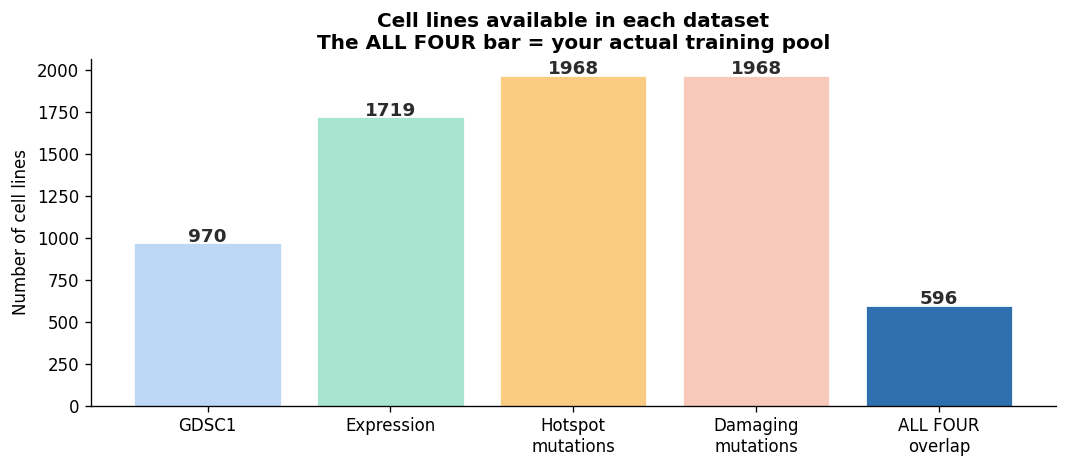


Proceeding with 596 cell lines.


In [ ]:
# Standardise to uppercase for comparison
gdsc_cls    = set(gdsc1['CELL_LINE_NAME'].str.upper())
expr_cls    = set(expr.index.str.upper())
hotspot_cls = set(hotspot.index.str.upper())
dam_cls     = set(damaging.index.str.upper())

# Overlaps
all_four    = gdsc_cls & expr_cls & hotspot_cls & dam_cls
all_three   = gdsc_cls & expr_cls & dam_cls  # without hotspot

print("=" * 50)
print(f"GDSC1:               {len(gdsc_cls):>5} cell lines")
print(f"Expression:          {len(expr_cls):>5} cell lines")
print(f"Hotspot mutations:   {len(hotspot_cls):>5} cell lines")
print(f"Damaging mutations:  {len(dam_cls):>5} cell lines")
print("=" * 50)
print(f"In ALL FOUR:         {len(all_four):>5}  ← full feature set")
print(f"GDSC + Expr + Dam:   {len(all_three):>5}  ← without hotspot")
print("=" * 50)

# Visualise
fig, ax = plt.subplots(figsize=(9, 4))
datasets = ['GDSC1', 'Expression', 'Hotspot\nmutations',
            'Damaging\nmutations', 'ALL FOUR\noverlap']
counts   = [len(gdsc_cls), len(expr_cls), len(hotspot_cls),
            len(dam_cls), len(all_four)]
colors   = ['#B5D4F4','#9FE1CB','#FAC775','#F5C4B3','#185FA5']

bars = ax.bar(datasets, counts, color=colors,
              alpha=0.9, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 8,
            str(val), ha='center',
            fontsize=11, fontweight='bold',
            color='#2C2C2A')

ax.set_title('Cell lines available in each dataset\n'
             'The ALL FOUR bar = your actual training pool',
             fontweight='bold')
ax.set_ylabel('Number of cell lines')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(PLOTS + 'cell_line_overlap.png', bbox_inches='tight')
plt.show()

# Use all_four as our working set
common_cls = sorted(list(all_four))
print(f"\nProceeding with {len(common_cls)} cell lines.")

In [ ]:
# Filter each dataset to only common cell lines
gdsc_filt = gdsc1[
    gdsc1['CELL_LINE_NAME'].str.upper().isin(all_four)
].copy()
gdsc_filt['CELL_LINE_NAME'] = gdsc_filt['CELL_LINE_NAME'].str.upper()

expr_filt = expr[
    expr.index.str.upper().isin(all_four)
].copy()
expr_filt.index = expr_filt.index.str.upper()

hotspot_filt = hotspot[
    hotspot.index.str.upper().isin(all_four)
].copy()
hotspot_filt.index = hotspot_filt.index.str.upper()

dam_filt = damaging[
    damaging.index.str.upper().isin(all_four)
].copy()
dam_filt.index = dam_filt.index.str.upper()

print("After filtering to common cell lines:")
print(f"  GDSC1:      {gdsc_filt.shape}")
print(f"  Expression: {expr_filt.shape}")
print(f"  Hotspot:    {hotspot_filt.shape}")
print(f"  Damaging:   {dam_filt.shape}")

expected_rows = len(common_cls) * gdsc_filt['DRUG_NAME'].nunique()
print(f"\nExpected ML matrix rows: ~{expected_rows:,}")
print(f"  ({len(common_cls)} cell lines × "
      f"{gdsc_filt['DRUG_NAME'].nunique()} drugs)")

After filtering to common cell lines:
  GDSC1:      (204238, 19)
  Expression: (596, 19215)
  Hotspot:    (596, 553)
  Damaging:   (596, 19505)

Expected ML matrix rows: ~225,288
  (596 cell lines × 378 drugs)


In [ ]:
# ── Step 1: Build the labels table ─────────────────────────
# Small table: cell line + drug + what we predict
# 225k rows × 6 columns — tiny

labels = gdsc_filt[[
    'CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_NAME',
    'PUTATIVE_TARGET', 'PATHWAY_NAME',
    'LN_IC50', 'AUC'
]].copy().reset_index(drop=True)

print(f"Labels table: {labels.shape}")
print(f"Memory: {labels.memory_usage(deep=True).sum()/1e6:.1f} MB")
display(labels.head(3))

# ── Step 2: Build the features table ───────────────────────
# One row per cell line — no duplication
# 596 rows × (19,215 + 553 + 19,505) columns

print("\nBuilding features table (one row per cell line)...")

# Combine expression + hotspot + damaging side by side
# This is only 596 rows — perfectly manageable
features = pd.concat([
    expr_filt,
    hotspot_filt.add_suffix('_hotspot'),
    dam_filt.add_suffix('_damaging')
], axis=1)

print(f"Features table: {features.shape}")
print(f"Memory: {features.memory_usage(deep=True).sum()/1e6:.1f} MB")

# ── Step 3: Verify the join will work ──────────────────────
# Quick test: can we look up MCF7's features?
sample_cl = labels['CELL_LINE_NAME'].iloc[0]
if sample_cl in features.index:
    print(f"\nLookup test passed: '{sample_cl}' found in features")
else:
    print(f"\nWARNING: '{sample_cl}' NOT found in features — check casing")

Labels table: (204238, 7)
Memory: 62.9 MB


,CELL_LINE_NAME,TCGA_DESC,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,LN_IC50,AUC
0,SK-ES-1,UNCLASSIFIED,Erlotinib,EGFR,EGFR signaling,2.033564,0.950758
1,8-MG-BA,GBM,Erlotinib,EGFR,EGFR signaling,2.493943,0.980200
2,GB-1,GBM,Erlotinib,EGFR,EGFR signaling,3.603243,0.984624



Building features table (one row per cell line)...
Features table: (596, 39273)
Memory: 187.3 MB

Lookup test passed: 'SK-ES-1' found in features


In [ ]:
import os

# Save labels (small — save as CSV so you can inspect it)
labels_path = MODELS + 'labels.csv'
labels.to_csv(labels_path, index=False)
print(f"Labels saved:   {labels_path}")
print(f"Size: {os.path.getsize(labels_path)/1e6:.1f} MB")

# Save features (larger — use parquet, much faster to load)
features_path = MODELS + 'features.parquet'
features.to_parquet(features_path)
print(f"Features saved: {features_path}")
print(f"Size: {os.path.getsize(features_path)/1e6:.1f} MB")

print(f"\n{'='*50}")
print(f"PHASE 2 COMPLETE")
print(f"{'='*50}")
print(f"Labels:   {labels.shape[0]:,} rows × {labels.shape[1]} cols")
print(f"Features: {features.shape[0]:,} rows × {features.shape[1]:,} cols")
print(f"\nHow these connect:")
print(f"  labels['CELL_LINE_NAME']  →  features.index")
print(f"  labels['LN_IC50']         →  what your model predicts")
print(f"  features columns          →  what your model uses to predict")

Labels saved:   /content/drive/MyDrive/anticancer_project/models/labels.csv
Size: 14.5 MB
Features saved: /content/drive/MyDrive/anticancer_project/models/features.parquet
Size: 113.2 MB

PHASE 2 COMPLETE
Labels:   204,238 rows × 7 cols
Features: 596 rows × 39,273 cols

How these connect:
  labels['CELL_LINE_NAME']  →  features.index
  labels['LN_IC50']         →  what your model predicts
  features columns          →  what your model uses to predict


In [ ]:
# This is how Phase 3 will use these tables
# We never merge everything — we look up features on the fly

print("Demo: how to get features for one training batch\n")

# Get a small batch of 5 experiments
batch = labels.sample(5, random_state=42)[
    ['CELL_LINE_NAME','DRUG_NAME','LN_IC50']
]

# Look up features for just those cell lines
batch_cls = batch['CELL_LINE_NAME'].values
batch_features = features.loc[batch_cls]

print("Batch labels:")
display(batch.reset_index(drop=True))

print(f"\nBatch features shape: {batch_features.shape}")
print(f"(5 cell lines × {features.shape[1]:,} features)")
print(f"\nFirst 5 feature values for first row:")
print(batch_features.iloc[0, :5].to_dict())

print(f"\nThis is how XGBoost/LightGBM will see the data —")
print(f"features looked up per cell line, target from labels.")

Demo: how to get features for one training batch

Batch labels:


,CELL_LINE_NAME,DRUG_NAME,LN_IC50
0,MKN1,VX-702,3.048360
1,NCI-H810,Y-39983,3.605799
2,KYSE-180,LIMK1 inhibitor BMS4,4.647009
3,NUGC-4,AZ20,1.631357
4,NH-12,CAY10603,-1.081537



Batch features shape: (5, 39273)
(5 cell lines × 39,273 features)

First 5 feature values for first row:
{'RBM5': 6.1782383919, 'RBM6': 5.1937718391, 'SLC25A13': 5.3871417046, 'CACNG3': 0.0266853478, 'ZNF263': 3.9621696472}

This is how XGBoost/LightGBM will see the data —
features looked up per cell line, target from labels.


# Phase 3 Feature Selection:
#### Naive approach of using Max variance across the feature column to select a feature.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA   = '/content/drive/MyDrive/anticancer_project/data/'
MODELS = '/content/drive/MyDrive/anticancer_project/models/'
PLOTS  = '/content/drive/MyDrive/anticancer_project/plots/'

plt.rcParams['figure.dpi'] = 120

print("Loading labels...")
labels = pd.read_csv(MODELS + 'labels.csv')

print("Loading features...")
features = pd.read_parquet(MODELS + 'features.parquet')

print(f"\nLabels:   {labels.shape}")
print(f"Features: {features.shape}")
print(f"\nLabel columns: {labels.columns.tolist()}")
print(f"\nSample labels:")
display(labels.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading labels...
Loading features...

Labels:   (204238, 7)
Features: (596, 39273)

Label columns: ['CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME', 'LN_IC50', 'AUC']

Sample labels:


,CELL_LINE_NAME,TCGA_DESC,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,LN_IC50,AUC
0,SK-ES-1,UNCLASSIFIED,Erlotinib,EGFR,EGFR signaling,2.033564,0.950758
1,8-MG-BA,GBM,Erlotinib,EGFR,EGFR signaling,2.493943,0.980200
2,GB-1,GBM,Erlotinib,EGFR,EGFR signaling,3.603243,0.984624


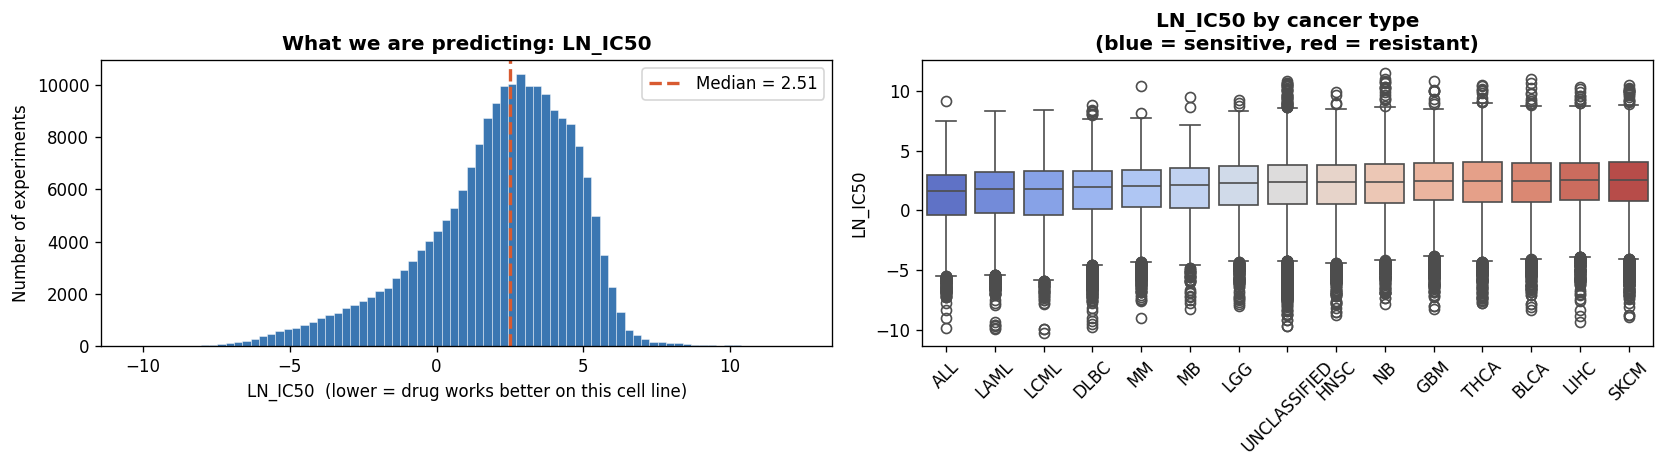

Missing LN_IC50 values: 0
Labels after removing missing: 204,238 rows


In [ ]:
# LN_IC50 is what we predict
# Let's understand its distribution before doing anything else

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution of LN_IC50
axes[0].hist(labels['LN_IC50'].dropna(), bins=80,
             color='#185FA5', alpha=0.85,
             edgecolor='white', linewidth=0.3)
axes[0].axvline(labels['LN_IC50'].median(), color='#D85A30',
                lw=2, ls='--',
                label=f"Median = {labels['LN_IC50'].median():.2f}")
axes[0].set_title('What we are predicting: LN_IC50', fontweight='bold')
axes[0].set_xlabel('LN_IC50  (lower = drug works better on this cell line)')
axes[0].set_ylabel('Number of experiments')
axes[0].legend()

# Per cancer type
cancer_ic50 = labels.merge(
    pd.DataFrame({'CELL_LINE_NAME': features.index}),
    on='CELL_LINE_NAME', how='inner'
)
order = (labels.groupby('TCGA_DESC')['LN_IC50']
               .median()
               .sort_values()
               .index[:15])  # top 15 cancer types
sns.boxplot(data=labels[labels['TCGA_DESC'].isin(order)],
            x='TCGA_DESC', y='LN_IC50',
            order=order, ax=axes[1], palette='coolwarm')
axes[1].set_title('LN_IC50 by cancer type\n(blue = sensitive, red = resistant)',
                  fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig(PLOTS + 'target_distribution.png', bbox_inches='tight')
plt.show()

# Remove rows with missing LN_IC50
missing = labels['LN_IC50'].isnull().sum()
print(f"Missing LN_IC50 values: {missing}")
labels = labels.dropna(subset=['LN_IC50']).reset_index(drop=True)
print(f"Labels after removing missing: {len(labels):,} rows")

Computing feature variance...
(This is across 596 cell lines — how much does each gene vary?)

Expression columns:  19,215
Hotspot columns:     553
Damaging columns:    19,505

Expression variance stats:
  Min variance:    0.0000
  Median variance: 0.5626
  Max variance:    16.4866


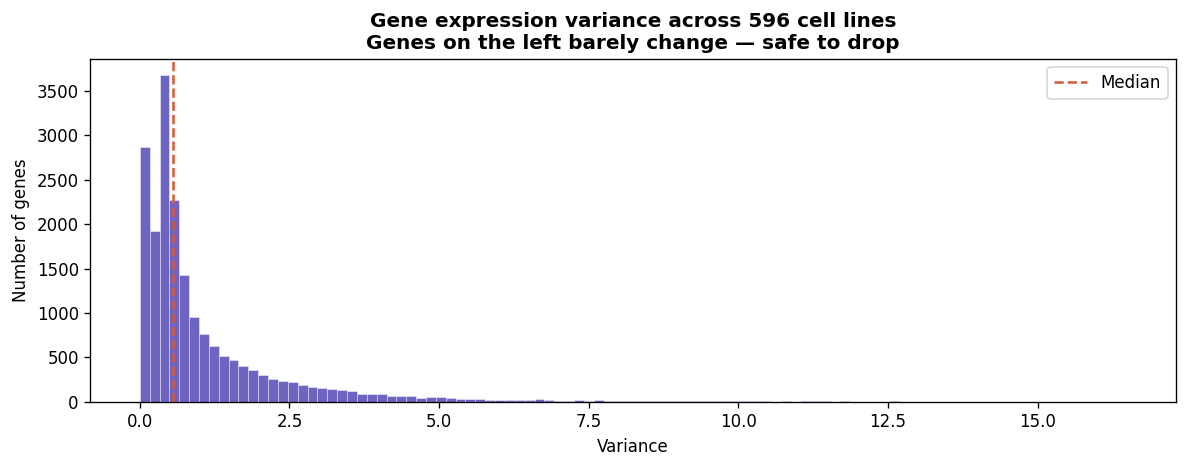

In [ ]:
# Strategy: keep only genes where expression varies meaningfully
# across cell lines. If a gene has the same value in every cell line,
# it carries zero information — the model can't use it.
#
# We measure this with VARIANCE — how spread out the values are.
# Low variance = boring gene, same everywhere = useless feature
# High variance = interesting gene, differs between cell lines = useful

print("Computing feature variance...")
print("(This is across 596 cell lines — how much does each gene vary?)\n")

# Separate the three feature types
expr_cols    = [c for c in features.columns if not c.endswith('_hotspot')
                and not c.endswith('_damaging')]
hotspot_cols = [c for c in features.columns if c.endswith('_hotspot')]
damaging_cols= [c for c in features.columns if c.endswith('_damaging')]

print(f"Expression columns:  {len(expr_cols):,}")
print(f"Hotspot columns:     {len(hotspot_cols):,}")
print(f"Damaging columns:    {len(damaging_cols):,}")

# Compute variance for expression genes only
# (mutations are already binary 0/1 — different selection strategy)
expr_variance = features[expr_cols].var(axis=0)

print(f"\nExpression variance stats:")
print(f"  Min variance:    {expr_variance.min():.4f}")
print(f"  Median variance: {expr_variance.median():.4f}")
print(f"  Max variance:    {expr_variance.max():.4f}")

# Plot variance distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(expr_variance, bins=100,
        color='#534AB7', alpha=0.85,
        edgecolor='white', linewidth=0.3)
ax.axvline(expr_variance.median(), color='#D85A30',
           lw=1.5, ls='--', label='Median')
ax.set_title('Gene expression variance across 596 cell lines\n'
             'Genes on the left barely change — safe to drop',
             fontweight='bold')
ax.set_xlabel('Variance')
ax.set_ylabel('Number of genes')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS + 'gene_variance.png', bbox_inches='tight')
plt.show()

In [ ]:
# Keep top 3,000 most variable expression genes
# Why 3,000? Enough signal, manageable for LightGBM, standard in literature
N_GENES = 2700

top_genes = expr_variance.nlargest(N_GENES).index.tolist()

print(f"Keeping top {N_GENES} most variable expression genes")
print(f"Dropping {len(expr_cols) - N_GENES:,} low-variance genes")

# For mutations: keep genes mutated in at least 2% of cell lines
# If a gene is mutated in only 1 cell line out of 596,
# the model can't learn anything reliable from it
MIN_MUTATION_FREQ = 0.02
n_min = int(MIN_MUTATION_FREQ * len(features))

hotspot_freq  = features[hotspot_cols].sum(axis=0)
damaging_freq = features[damaging_cols].sum(axis=0)

top_hotspot  = hotspot_freq[hotspot_freq >= n_min].index.tolist()
top_damaging = damaging_freq[damaging_freq >= n_min].index.tolist()

print(f"\nHotspot genes with ≥{MIN_MUTATION_FREQ*100:.0f}% frequency: "
      f"{len(top_hotspot)} (of {len(hotspot_cols)})")
print(f"Damaging genes with ≥{MIN_MUTATION_FREQ*100:.0f}% frequency: "
      f"{len(top_damaging)} (of {len(damaging_cols)})")

# Build filtered feature matrix
selected_cols = top_genes + top_hotspot + top_damaging
features_sel  = features[selected_cols].copy()

print(f"\nFeature matrix: {len(features.columns):,} → {len(selected_cols):,} columns")
print(f"  Expression:  {len(top_genes):,}")
print(f"  Hotspot:     {len(top_hotspot)}")
print(f"  Damaging:    {len(top_damaging)}")

Keeping top 2700 most variable expression genes
Dropping 16,515 low-variance genes

Hotspot genes with ≥2% frequency: 19 (of 553)
Damaging genes with ≥2% frequency: 529 (of 19505)

Feature matrix: 39,273 → 3,248 columns
  Expression:  2,700
  Hotspot:     19
  Damaging:    529


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# Why GroupShuffleSplit?
# Normal train_test_split would put MCF7+Erlotinib in train
# and MCF7+Lapatinib in test.
# The model would see MCF7's gene profile during training,
# then be asked to predict MCF7's response to a different drug.
# That's cheating — in the real world you get a NEW patient,
# not a different drug for a known patient.
#
# GroupShuffleSplit keeps ALL rows for a cell line
# either entirely in train or entirely in test.

cell_lines = labels['CELL_LINE_NAME'].values

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(labels, groups=cell_lines))

train_labels = labels.iloc[train_idx].reset_index(drop=True)
test_labels  = labels.iloc[test_idx].reset_index(drop=True)

# Verify no cell line appears in both sets
train_cls = set(train_labels['CELL_LINE_NAME'])
test_cls  = set(test_labels['CELL_LINE_NAME'])
overlap   = train_cls & test_cls

print("=" * 50)
print(f"Training set:  {len(train_labels):,} rows, "
      f"{len(train_cls)} cell lines")
print(f"Test set:      {len(test_labels):,} rows,  "
      f"{len(test_cls)} cell lines")
print(f"Cell line overlap between train/test: {len(overlap)}")
print("(Must be 0 — if not, something is wrong)")
print("=" * 50)

if len(overlap) == 0:
    print("\nSplit is clean. No data leakage.")
else:
    print(f"\nWARNING: {len(overlap)} cell lines appear in both sets!")

Training set:  163,813 rows, 476 cell lines
Test set:      40,425 rows,  120 cell lines
Cell line overlap between train/test: 0
(Must be 0 — if not, something is wrong)

Split is clean. No data leakage.


In [ ]:
from sklearn.preprocessing import LabelEncoder

def build_Xy_with_drug(label_df, feature_df, feature_cols):
    """
    Build feature matrix including BOTH:
    - Cell line features (gene expression + mutations)
    - Drug identity features (one-hot encoded drug name)

    This is critical — without drug features the model
    can't distinguish which drug it's predicting for.
    """
    cl_names  = label_df['CELL_LINE_NAME'].values
    drug_names = label_df['DRUG_NAME'].values
    y = label_df['LN_IC50'].values.astype('float32')

    # ── Part 1: Cell line features (same as before) ──────────
    n_rows    = len(cl_names)
    n_bio     = len(feature_cols)
    X_bio     = np.empty((n_rows, n_bio), dtype='float32')

    chunk_size = 10_000
    for start in range(0, n_rows, chunk_size):
        end = min(start + chunk_size, n_rows)
        X_bio[start:end] = feature_df.loc[
            cl_names[start:end], feature_cols
        ].values
        if start % 50_000 == 0:
            print(f"  Cell features: {start:,} / {n_rows:,}")

    # ── Part 2: Drug one-hot encoding ────────────────────────
    # Get all unique drugs from the full labels (not just this split)
    all_drugs = sorted(labels['DRUG_NAME'].unique())
    drug_to_idx = {d: i for i, d in enumerate(all_drugs)}
    n_drugs = len(all_drugs)

    X_drug = np.zeros((n_rows, n_drugs), dtype='float32')
    for i, drug in enumerate(drug_names):
        if drug in drug_to_idx:
            X_drug[i, drug_to_idx[drug]] = 1.0

    # ── Part 3: Drug pathway encoding ────────────────────────
    # Also encode pathway as a number — gives model semantic drug info
    all_pathways = sorted(labels['PATHWAY_NAME'].dropna().unique())
    path_to_idx = {p: i for i, p in enumerate(all_pathways)}

    #X_pathway = np.zeros((n_rows, 1), dtype='float32')
    #for i, row in enumerate(label_df['PATHWAY_NAME'].values):
    #    X_pathway[i, 0] = path_to_idx.get(str(row), -1)

    # ── Combine everything ────────────────────────────────────
    #X = np.hstack([X_bio, X_drug, X_pathway])
    X = np.hstack([X_bio, X_drug])

    #Removing X_pathway because we already got one-hot encoded Drugs and adding pathway again was duplication, pathway hold: EGFR signaling = 0, DNA damage = 1, Hormone = 2...

    return X, y, all_drugs

print("Building training matrix WITH drug features...")
X_train, y_train, all_drugs = build_Xy_with_drug(
    train_labels, features_sel, features_sel.columns.tolist()
)

print("\nBuilding test matrix WITH drug features...")
X_test, y_test, _ = build_Xy_with_drug(
    test_labels, features_sel, features_sel.columns.tolist()
)

n_bio   = len(features_sel.columns)
n_drugs = len(all_drugs)

print(f"\nX_train: {X_train.shape}")
print(f"  Cell line features:  {n_bio:,}")
print(f"  Drug one-hot cols:   {n_drugs}")
print(f"  Pathway col:         1")
print(f"  Total:               {X_train.shape[1]:,}")
print(f"\nMemory: {X_train.nbytes/1e6:.0f} MB")

Building training matrix WITH drug features...
  Cell features: 0 / 163,813
  Cell features: 50,000 / 163,813
  Cell features: 100,000 / 163,813
  Cell features: 150,000 / 163,813

Building test matrix WITH drug features...
  Cell features: 0 / 40,425

X_train: (163813, 3626)
  Cell line features:  3,248
  Drug one-hot cols:   378
  Pathway col:         1
  Total:               3,626

Memory: 2376 MB


# Model Loading and Training (LightGBM)

In [ ]:
import lightgbm as lgb
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import subprocess, gc

# ── Step 1: Check hardware ────────────────────────────────────────────
gpu_check = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
has_gpu   = gpu_check.returncode == 0
print(f"GPU available: {has_gpu}")
if has_gpu:
    # Print which GPU you have
    for line in gpu_check.stdout.split('\n'):
        if 'Tesla' in line or 'T4' in line or 'A100' in line or 'RTX' in line:
            print(f"GPU model: {line.strip()}")

# ── Step 2: Report exactly what we're working with ────────────────────
print(f"\nData going into training:")
print(f"  X_train: {X_train.shape[0]:,} rows × {X_train.shape[1]:,} features")
print(f"  X_test:  {X_test.shape[0]:,}  rows × {X_test.shape[1]:,} features")
print(f"  X_train RAM: {X_train.nbytes/1e6:.0f} MB")
print(f"  X_test  RAM: {X_test.nbytes/1e6:.0f} MB")
print(f"  Estimated LightGBM peak: ~{X_train.nbytes/1e6 * 4:.0f} MB")
print(f"  dtype: {X_train.dtype}  (float16 = 2 bytes/number, float32 = 4)")

# ── Step 2: Convert to LightGBM Dataset format ─────────────
# This is LightGBM's own internal format
# It compresses data into histograms upfront — uses ~3x less RAM
# than passing raw numpy arrays during fit()
print("\nConverting to LightGBM Dataset format...")
print("(This compresses data — takes ~1 min but saves RAM during training)")

dtrain = lgb.Dataset(
    X_train, label=y_train,
    free_raw_data=True   # release raw numpy array after conversion
)
print(f"  Training dataset created.")
print(f"\nStep 2/4 — Compressing test data...")
dtest = lgb.Dataset(
    X_test, label=y_test,
    reference=dtrain,
    free_raw_data=True
)
print(f"  Test dataset created.")

# Free the numpy arrays — Dataset has what it needs now
del X_train, X_test
import gc; gc.collect()
print("Raw arrays freed from memory.")

# ── Step 3: Train using lgb.train (lower level, more control) ─
params = {
    'objective':        'regression',
    'metric':           'rmse',
    'learning_rate':    0.05,
    'num_leaves':       63,
    'min_child_samples': 20,
    'subsample':        0.8,
    'subsample_freq':    1,
    'colsample_bytree': 0.3,
    'random_state':     42,
    'n_jobs':           -1,
    'verbose':          -1,

    'max_bin':           180,

    'reg_alpha':    0.1,   # L1 regularization — pushes small weights to zero
    'reg_lambda':   1.0,   # L2 regularization — penalizes large weights
    'min_gain_to_split': 0.01,  # only split if it actually helps

    # GPU settings — LightGBM switches automatically if no GPU found
    'device':           'gpu' if has_gpu else 'cpu',
    'gpu_platform_id':  0,
    'gpu_device_id':    0,
    'verbose':         -1,
}

print(f"\nTraining on: {'GPU' if has_gpu else 'CPU'}")
print("Training LightGBM...\n")
print(f"\nKey parameters:")
print(f"  num_leaves:      {params['num_leaves']}  (complexity per tree)")
print(f"  learning_rate:   {params['learning_rate']}  (step size)")
print(f"  max_bin:         {params['max_bin']}   (histogram bins — lower = less RAM)")
print(f"  device:          {params['device']}")


callbacks = [
    lgb.early_stopping(stopping_rounds=90, verbose=True),
    lgb.log_evaluation(period=100)
]

booster = lgb.train(
    params,
    dtrain,
    num_boost_round  = 1500,
    valid_sets       = [dtrain,dtest],
    valid_names      = ['train','test'],
    callbacks        = callbacks
)

print(f"\nTraining complete.")
print(f"Best iteration: {booster.best_iteration}")

GPU available: True
GPU model: |   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |

Data going into training:
  X_train: 163,813 rows × 3,626 features
  X_test:  40,425  rows × 3,626 features
  X_train RAM: 2376 MB
  X_test  RAM: 586 MB
  Estimated LightGBM peak: ~9504 MB
  dtype: float32  (float16 = 2 bytes/number, float32 = 4)

Converting to LightGBM Dataset format...
(This compresses data — takes ~1 min but saves RAM during training)
  Training dataset created.

Step 2/4 — Compressing test data...
  Test dataset created.
Raw arrays freed from memory.

Training on: GPU
Training LightGBM...


Key parameters:
  num_leaves:      63  (complexity per tree)
  learning_rate:   0.05  (step size)
  max_bin:         180   (histogram bins — lower = less RAM)
  device:          gpu
Training until validation scores don't improve for 90 rounds
[100]	train's rmse: 1.38858	test's rmse: 1.46969
[200]	train's rmse: 1.19621	test's rmse: 1.31458
[300]	train's rmse

Rebuilding test matrix for evaluation...
  Cell features: 0 / 40,425
  Pearson r:  0.8820   (target: > 0.7)
  RMSE:       1.2188  (lower is better)
  p-value:    0.00e+00


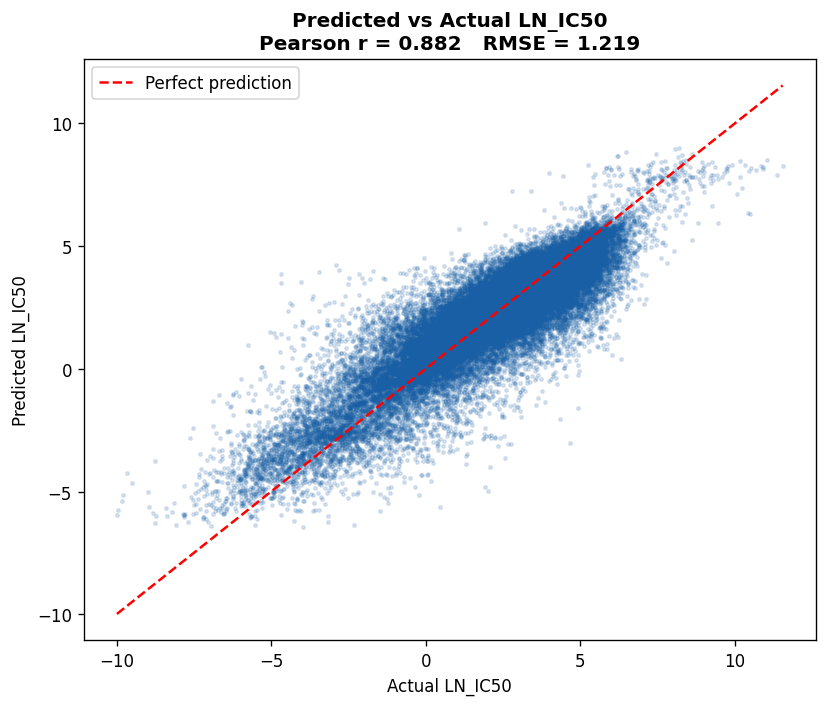

In [ ]:
# Rebuild X_test for evaluation
# (we deleted it to save RAM — rebuild just the test portion)
print("Rebuilding test matrix for evaluation...")
X_test_eval, y_test_eval,_ = build_Xy_with_drug(
    test_labels, features_sel,
    features_sel.columns.tolist()
)

y_pred = booster.predict(X_test_eval,
                         num_iteration=booster.best_iteration)

r, p_value = pearsonr(y_test_eval, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_eval, y_pred))

print("=" * 45)
print(f"  Pearson r:  {r:.4f}   (target: > 0.7)")
print(f"  RMSE:       {rmse:.4f}  (lower is better)")
print(f"  p-value:    {p_value:.2e}")
print("=" * 45)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_eval, y_pred, alpha=0.15, s=4,
           color='#185FA5', rasterized=True)
lims = [min(y_test_eval.min(), y_pred.min()),
        max(y_test_eval.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual LN_IC50')
ax.set_ylabel('Predicted LN_IC50')
ax.set_title(f'Predicted vs Actual LN_IC50\n'
             f'Pearson r = {r:.3f}   RMSE = {rmse:.3f}',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS + 'baseline_predictions.png', bbox_inches='tight')
plt.show()

Gene/mutation features:  3248
Drug one-hot features:   378
Total feature names:     3626
Booster expects:         3626

Top 20 most important features:


,feature,importance
3540,DRUG_SN-38,307999.175554
3405,DRUG_Gemcitabine,193427.888709
3360,DRUG_Docetaxel,191836.951276
3371,DRUG_Epothilone B,186013.198909
3592,DRUG_Vinblastine,148486.189173
3593,DRUG_Vinorelbine,134720.488159
3575,DRUG_Thapsigargin,132584.228261
3549,DRUG_Sepantronium bromide,125594.253650
3274,DRUG_AZD4877,120497.679640
3362,DRUG_Doxorubicin,111869.094141



Top 10 biological features (genes + mutations):


,feature,importance
666,ATP1B1,37757.538990
160,GMFG,34901.573160
439,PTPN7,20904.700871
1069,TJP1,19335.248027
1191,TEAD1,18417.411756
233,CD53,14147.034937
315,CLDN3,12667.578804
1419,ABCB1,11795.436117
612,DUSP23,11195.525435
1896,LURAP1L,10946.047946



Top 10 most predictive drugs:


,feature,importance
3540,DRUG_SN-38,307999.175554
3405,DRUG_Gemcitabine,193427.888709
3360,DRUG_Docetaxel,191836.951276
3371,DRUG_Epothilone B,186013.198909
3592,DRUG_Vinblastine,148486.189173
3593,DRUG_Vinorelbine,134720.488159
3575,DRUG_Thapsigargin,132584.228261
3549,DRUG_Sepantronium bromide,125594.253650
3274,DRUG_AZD4877,120497.679640
3362,DRUG_Doxorubicin,111869.094141


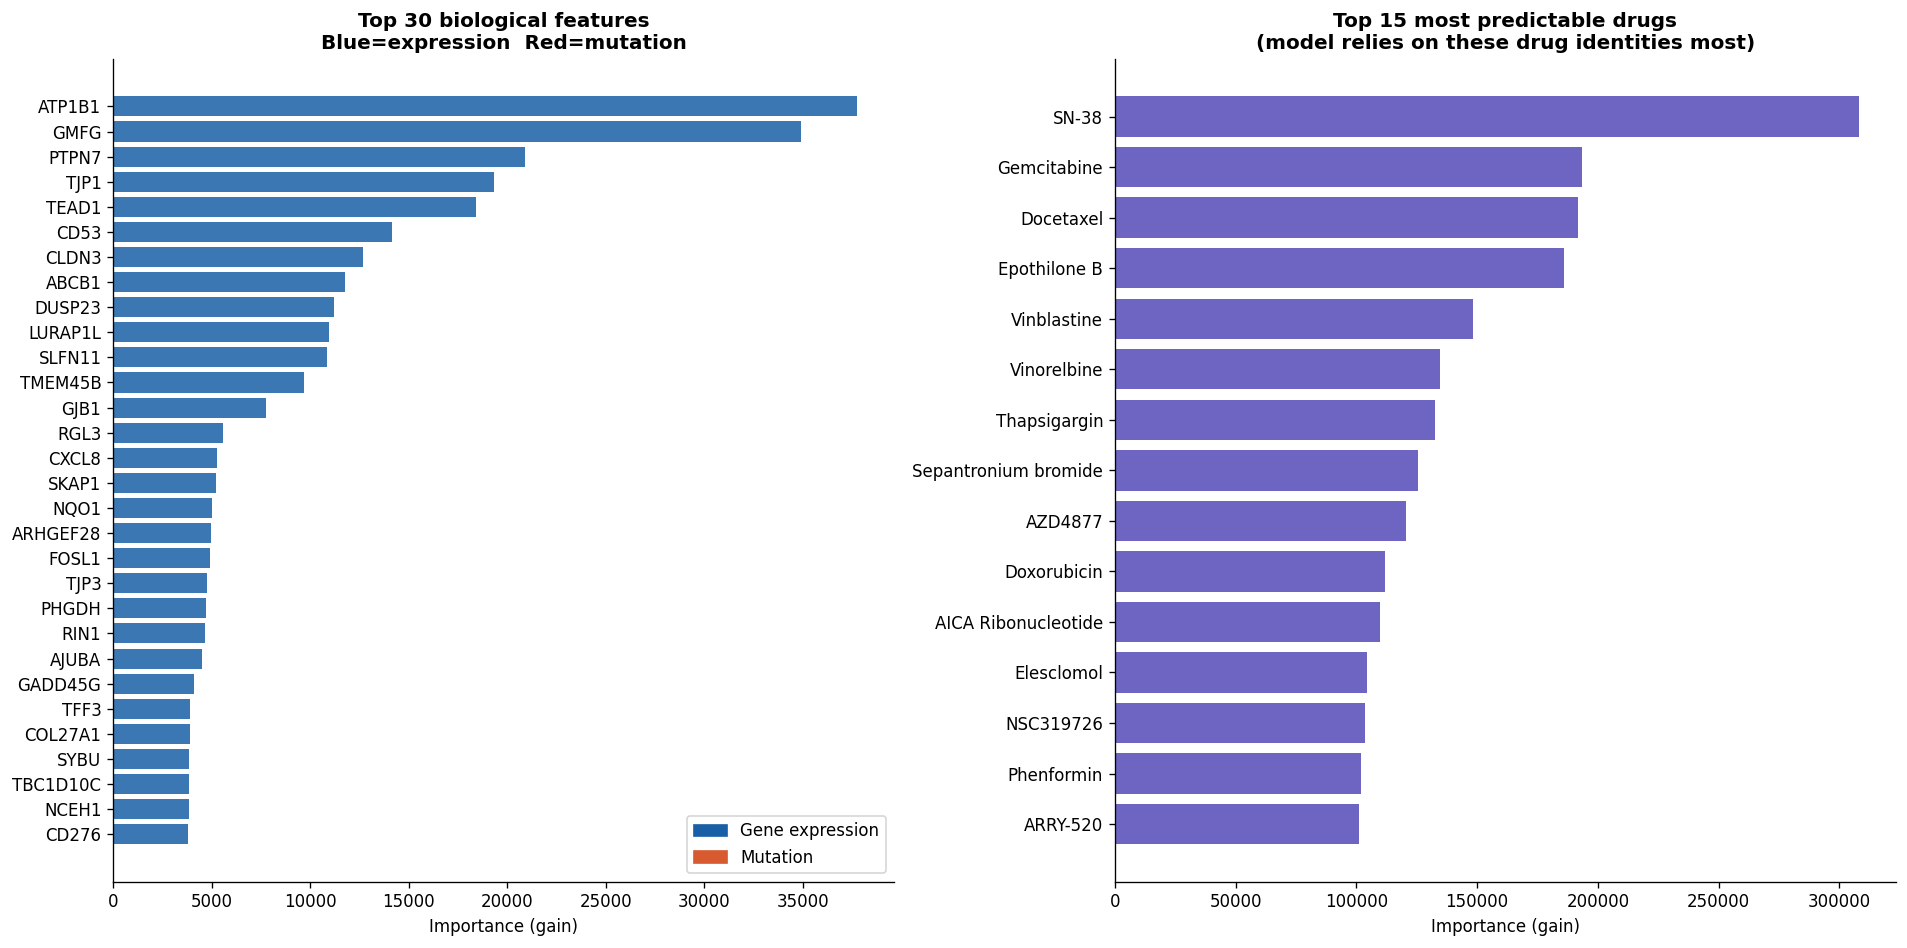


Model saved.


In [ ]:
# Rebuild the full feature name list in the exact same order
# that build_Xy_with_drug stacked the columns

# Part 1 — gene and mutation column names (from features_sel)
gene_cols = features_sel.columns.tolist()

# Part 2 — drug one-hot column names
drug_cols = [f'DRUG_{d}' for d in sorted(labels['DRUG_NAME'].unique())]

# Part 3 — pathway column name
#pathway_cols = ['PATHWAY_encoded']

# Combined — must match exact order in build_Xy_with_drug
all_feature_names = gene_cols + drug_cols #+ pathway_cols

print(f"Gene/mutation features:  {len(gene_cols)}")
print(f"Drug one-hot features:   {len(drug_cols)}")
#print(f"Pathway feature:         {len(pathway_cols)}")
print(f"Total feature names:     {len(all_feature_names)}")
print(f"Booster expects:         {len(booster.feature_importance())}")

# Confirm they match before building the dataframe
assert len(all_feature_names) == len(booster.feature_importance()), \
    f"Still mismatched: {len(all_feature_names)} names vs {len(booster.feature_importance())} importances"

# Build importances dataframe
importances = pd.DataFrame({
    'feature':    all_feature_names,
    'importance': booster.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print(f"\nTop 20 most important features:")
display(importances.head(20))

# Separate biological features from drug features
bio_imp  = importances[~importances['feature'].str.startswith('DRUG_')]
drug_imp = importances[importances['feature'].str.startswith('DRUG_')]

print(f"\nTop 10 biological features (genes + mutations):")
display(bio_imp.head(10))

print(f"\nTop 10 most predictive drugs:")
display(drug_imp.head(10))

# Plot — biological features only (more interesting)
top30_bio = bio_imp.head(30)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left — top biological features
colors = ['#185FA5' if not f.endswith(('_hotspot','_damaging'))
          else '#D85A30'
          for f in top30_bio['feature']]
axes[0].barh(top30_bio['feature'][::-1],
             top30_bio['importance'][::-1],
             color=colors[::-1], alpha=0.85)
axes[0].set_title('Top 30 biological features\nBlue=expression  Red=mutation',
                  fontweight='bold')
axes[0].set_xlabel('Importance (gain)')
axes[0].spines[['top','right']].set_visible(False)

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#185FA5', label='Gene expression'),
    Patch(color='#D85A30', label='Mutation')
])

# Right — top drug features (which drugs are most predictable)
top15_drug = drug_imp.head(15).copy()
top15_drug['drug_name'] = top15_drug['feature'].str.replace('DRUG_','')
axes[1].barh(top15_drug['drug_name'][::-1],
             top15_drug['importance'][::-1],
             color='#534AB7', alpha=0.85)
axes[1].set_title('Top 15 most predictable drugs\n(model relies on these drug identities most)',
                  fontweight='bold')
axes[1].set_xlabel('Importance (gain)')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS + 'feature_importance_fixed.png', bbox_inches='tight')
plt.show()

# Save model
booster.save_model(MODELS + 'lgbm_baseline.txt')
print("\nModel saved.")

# SHAP Values

Computing SHAP values...
This shows WHY the model made each prediction, not just which features it used

  Cell features: 0 / 500
SHAP values shape: (500, 3626)
One SHAP value per feature per prediction

Top 20 biological features by SHAP:


,feature,shap_mean
160,GMFG,0.047407
666,ATP1B1,0.033227
612,DUSP23,0.028015
528,TMEM45B,0.025001
315,CLDN3,0.023966
1532,GJB1,0.022142
1069,TJP1,0.019976
1191,TEAD1,0.017928
2090,SKAP1,0.017606
439,PTPN7,0.017584


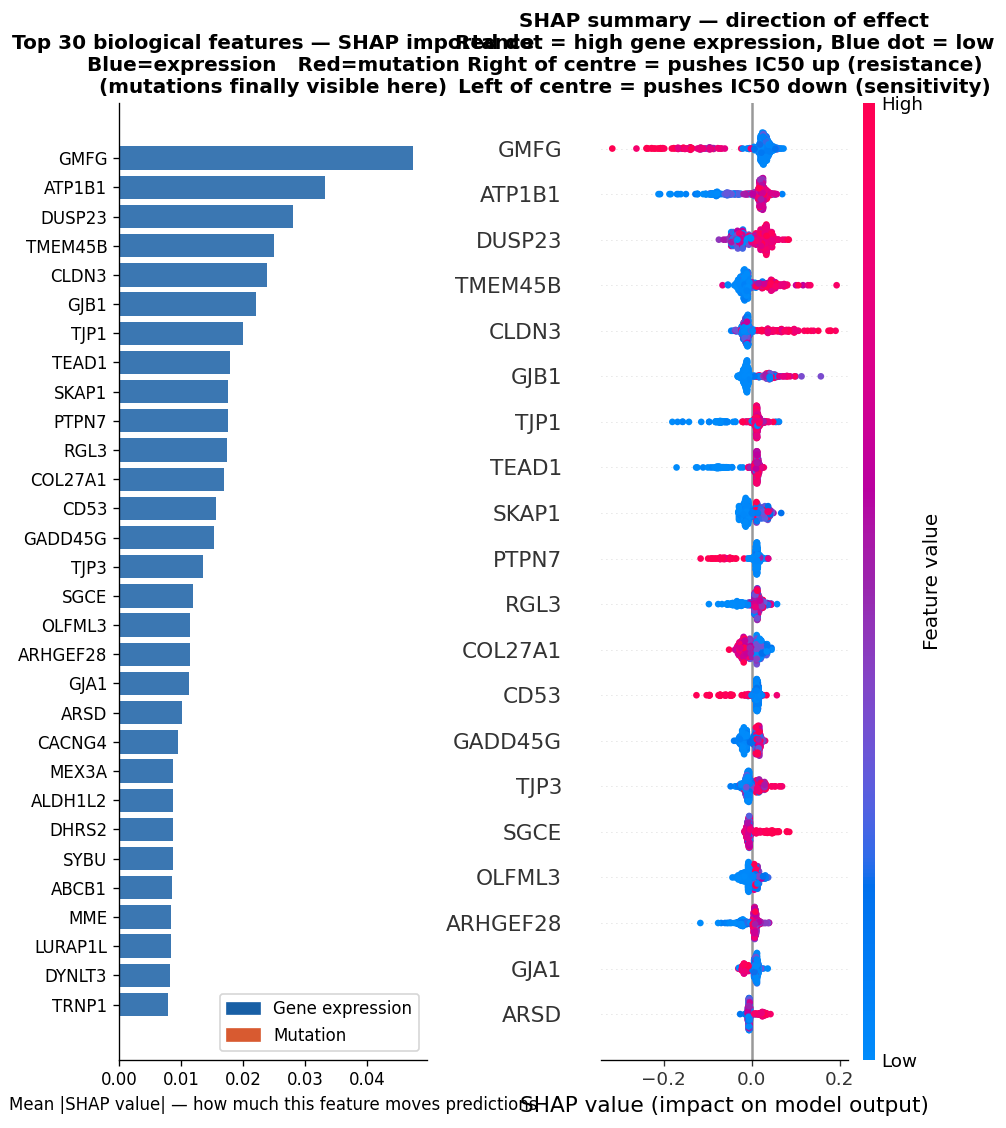

In [ ]:
import shap

print("Computing SHAP values...")
print("This shows WHY the model made each prediction, not just which features it used\n")

# Rebuild a sample of test data for SHAP
# SHAP on full test set takes too long — 500 rows is enough
sample_labels = test_labels.sample(500, random_state=42)
X_sample, y_sample, _ = build_Xy_with_drug(
    sample_labels, features_sel,
    features_sel.columns.tolist()
)

# Build explainer
explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_sample.astype('float32'))

print(f"SHAP values shape: {shap_values.shape}")
print(f"One SHAP value per feature per prediction")

# Rebuild full feature names (without pathway this time)
gene_cols    = features_sel.columns.tolist()
drug_cols    = [f'DRUG_{d}' for d in sorted(labels['DRUG_NAME'].unique())]
all_feat_names = gene_cols + drug_cols

# Mean absolute SHAP per feature
shap_importance = pd.DataFrame({
    'feature':    all_feat_names,
    'shap_mean':  np.abs(shap_values).mean(axis=0)
}).sort_values('shap_mean', ascending=False)

# Split biological vs drug
bio_shap  = shap_importance[~shap_importance['feature'].str.startswith('DRUG_')]
drug_shap = shap_importance[shap_importance['feature'].str.startswith('DRUG_')]

print("\nTop 20 biological features by SHAP:")
display(bio_shap.head(20))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Left — biological SHAP importance
top30 = bio_shap.head(30)
colors = ['#D85A30' if f.endswith(('_hotspot','_damaging'))
          else '#185FA5'
          for f in top30['feature']]
axes[0].barh(top30['feature'][::-1],
             top30['shap_mean'][::-1],
             color=colors[::-1], alpha=0.85)
axes[0].set_title('Top 30 biological features — SHAP importance\n'
                  'Blue=expression   Red=mutation\n'
                  '(mutations finally visible here)',
                  fontweight='bold')
axes[0].set_xlabel('Mean |SHAP value| — how much this feature moves predictions')
axes[0].spines[['top','right']].set_visible(False)
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#185FA5', label='Gene expression'),
    Patch(color='#D85A30', label='Mutation')
])

# Right — SHAP summary plot (shows direction, not just magnitude)
shap.summary_plot(
    shap_values[:, :len(gene_cols)],  # biological features only
    X_sample[:, :len(gene_cols)],
    feature_names=gene_cols,
    max_display=20,
    show=False,
    plot_type='dot'
)
plt.title('SHAP summary — direction of effect\n'
          'Red dot = high gene expression, Blue dot = low\n'
          'Right of centre = pushes IC50 up (resistance)\n'
          'Left of centre = pushes IC50 down (sensitivity)',
          fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS + 'shap_importance.png', bbox_inches='tight')
plt.show()

In [ ]:
# Take the same 500-sample test set you used for SHAP
# and show actual vs predicted side by side

y_sample_pred = booster.predict(
    X_sample.astype('float32'),
    num_iteration=booster.best_iteration
)

# Build a readable comparison table
comparison = sample_labels[['CELL_LINE_NAME','DRUG_NAME',
                             'LN_IC50']].copy().reset_index(drop=True)
comparison['PREDICTED']  = y_sample_pred.round(3)
comparison['ACTUAL']     = comparison['LN_IC50'].round(3)
comparison['ERROR']      = (comparison['PREDICTED'] -
                            comparison['ACTUAL']).round(3)
comparison['ABS_ERROR']  = comparison['ERROR'].abs().round(3)

# Sort by absolute error — worst predictions first
comparison_sorted = comparison.sort_values('ABS_ERROR', ascending=False)

print("=== WORST 10 PREDICTIONS ===")
display(comparison_sorted.head(10)[['CELL_LINE_NAME','DRUG_NAME',
                                    'ACTUAL','PREDICTED','ERROR']])

print("\n=== BEST 10 PREDICTIONS ===")
display(comparison_sorted.tail(10)[['CELL_LINE_NAME','DRUG_NAME',
                                    'ACTUAL','PREDICTED','ERROR']])

print(f"\n=== OVERALL STATS ===")
print(f"Mean absolute error:  {comparison['ABS_ERROR'].mean():.3f}")
print(f"Median absolute error:{comparison['ABS_ERROR'].median():.3f}")
print(f"% within 0.5 units:  {(comparison['ABS_ERROR'] < 0.5).mean()*100:.1f}%")
print(f"% within 1.0 units:  {(comparison['ABS_ERROR'] < 1.0).mean()*100:.1f}%")
print(f"% within 2.0 units:  {(comparison['ABS_ERROR'] < 2.0).mean()*100:.1f}%")
print(f"% beyond 2.0 units:  {(comparison['ABS_ERROR'] > 2.0).mean()*100:.1f}%")

# Now find PF-382 + Selisistat specifically
mask = ((comparison['CELL_LINE_NAME'] == 'PF-382') &
        (comparison['DRUG_NAME'] == 'Selisistat'))

if mask.sum() > 0:
    row = comparison[mask].iloc[0]
    print(f"\n=== PF-382 + SELISISTAT ===")
    print(f"Actual LN_IC50:    {row['ACTUAL']}")
    print(f"Predicted LN_IC50: {row['PREDICTED']}")
    print(f"Error:             {row['ERROR']}")
    print(f"\nConverted back to IC50 (µM):")
    print(f"  Actual:    e^{row['ACTUAL']:.2f} = {np.exp(row['ACTUAL']):.1f} µM")
    print(f"  Predicted: e^{row['PREDICTED']:.2f} = {np.exp(row['PREDICTED']):.1f} µM")
    print(f"\nBoth are high IC50 = resistant = drug doesn't work")
    print(f"GMFG pushed toward sensitivity but lost to other features")
else:
    print("\nPF-382 + Selisistat not in this 500-sample subset")
    print("Try finding it manually:")
    pf382 = comparison[comparison['CELL_LINE_NAME'] == 'PF-382']
    display(pf382.head(5))

=== WORST 10 PREDICTIONS ===


,CELL_LINE_NAME,DRUG_NAME,ACTUAL,PREDICTED,ERROR
230,SK-OV-3,LCL161,-2.816,4.021,6.837
180,MG-63,Sepantronium bromide,1.312,-3.554,-4.866
366,HSC-2,Daporinad,2.122,-2.716,-4.838
393,UACC-893,IGFR_3801,5.236,1.256,-3.980
374,RL,CGP-60474,1.131,-2.739,-3.870
110,WSU-NHL,Dasatinib,2.465,-1.376,-3.841
378,VCAP,I-BET-762,0.254,4.094,3.840
129,LU-65,PARP_9482,3.963,0.270,-3.693
483,EFM-192A,NSC319726,0.081,-3.603,-3.684
112,HT-144,BMS-754807,-2.906,0.523,3.429



=== BEST 10 PREDICTIONS ===


,CELL_LINE_NAME,DRUG_NAME,ACTUAL,PREDICTED,ERROR
256,FARAGE,Seliciclib,3.111,3.135,0.024
210,GI-ME-N,TAK-715,4.494,4.471,-0.023
329,JHOS-2,"MetAP2 Inhibitor, A832234",2.832,2.812,-0.020
196,CAOV-3,"Brivanib, BMS-540215",4.636,4.648,0.012
215,COLO-678,Gemcitabine,-2.409,-2.401,0.008
448,RL,FS106,0.610,0.603,-0.007
202,EFM-192A,Sphingosine Kinase 1 Inhibitor II,3.929,3.935,0.006
127,JHH-6,Embelin,2.805,2.800,-0.005
367,OVTOKO,FMK,5.072,5.068,-0.004
368,SNU-C1,AZD5582,3.257,3.254,-0.003



=== OVERALL STATS ===
Mean absolute error:  0.937
Median absolute error:0.754
% within 0.5 units:  37.4%
% within 1.0 units:  64.0%
% within 2.0 units:  89.6%
% beyond 2.0 units:  10.2%

=== PF-382 + SELISISTAT ===
Actual LN_IC50:    5.186
Predicted LN_IC50: 3.977
Error:             -1.209

Converted back to IC50 (µM):
  Actual:    e^5.19 = 178.8 µM
  Predicted: e^3.98 = 53.4 µM

Both are high IC50 = resistant = drug doesn't work
GMFG pushed toward sensitivity but lost to other features


In [ ]:
# Find the cell line with highest GMFG expression
# and strongest sensitivity prediction (most negative SHAP)
gmfg_idx = gene_cols.index('GMFG')
gmfg_shap = shap_values[:, gmfg_idx]

# Most negative SHAP = strongest sensitivity push
min_idx = np.argmin(gmfg_shap)

print(f"Outlier cell line: {sample_labels.iloc[min_idx]['CELL_LINE_NAME']}")
print(f"Drug tested:       {sample_labels.iloc[min_idx]['DRUG_NAME']}")
print(f"Actual LN_IC50:    {sample_labels.iloc[min_idx]['LN_IC50']:.3f}")
print(f"GMFG expression:   {features_sel.loc[sample_labels.iloc[min_idx]['CELL_LINE_NAME'], 'GMFG']:.3f}")
print(f"SHAP value:        {gmfg_shap[min_idx]:.3f}")
print(f"\nInterpretation:")
print(f"High GMFG ({features_sel.loc[sample_labels.iloc[min_idx]['CELL_LINE_NAME'], 'GMFG']:.2f}) ")
print(f"pushed IC50 prediction down by {abs(gmfg_shap[min_idx]):.3f} units")
print(f"meaning the model predicted this cell line is sensitive to {sample_labels.iloc[min_idx]['DRUG_NAME']}")

Outlier cell line: PF-382
Drug tested:       Selisistat
Actual LN_IC50:    5.186
GMFG expression:   8.639
SHAP value:        -0.317

Interpretation:
High GMFG (8.64) 
pushed IC50 prediction down by 0.317 units
meaning the model predicted this cell line is sensitive to Selisistat


In [ ]:
# Filter labels to Erlotinib only
erlotinib_labels = labels[labels['DRUG_NAME'] == 'Erlotinib'].copy()
print(f"Erlotinib experiments: {len(erlotinib_labels)}")
print(f"Cell lines: {erlotinib_labels['CELL_LINE_NAME'].nunique()}")

# Split by cell line
from sklearn.model_selection import GroupShuffleSplit
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(
    splitter.split(erlotinib_labels,
                   groups=erlotinib_labels['CELL_LINE_NAME'])
)

erl_train = erlotinib_labels.iloc[train_idx].reset_index(drop=True)
erl_test  = erlotinib_labels.iloc[test_idx].reset_index(drop=True)

# Build X and y — no drug one-hot needed (only one drug)
def build_Xy_single_drug(label_df, feature_df, feature_cols):
    cl_names = label_df['CELL_LINE_NAME'].values
    y = label_df['LN_IC50'].values.astype('float32')
    X = np.empty((len(cl_names), len(feature_cols)), dtype='float32')
    for start in range(0, len(cl_names), 1000):
        end = min(start + 1000, len(cl_names))
        X[start:end] = feature_df.loc[
            cl_names[start:end], feature_cols
        ].values
    return X, y

X_erl_train, y_erl_train = build_Xy_single_drug(
    erl_train, features_sel, features_sel.columns.tolist()
)
X_erl_test, y_erl_test = build_Xy_single_drug(
    erl_test, features_sel, features_sel.columns.tolist()
)

print(f"\nX_train: {X_erl_train.shape}")
print(f"X_test:  {X_erl_test.shape}")

Erlotinib experiments: 216
Cell lines: 216

X_train: (172, 3248)
X_test:  (44, 3248)


In [ ]:
print(f"\nData going into training:")
print(f"  X_erl_train: {X_erl_train.shape[0]:,} rows × {X_erl_train.shape[1]:,} features")
print(f"  X_erl_test:  {X_erl_test.shape[0]:,}  rows × {X_erl_test.shape[1]:,} features")
print(f"  X_erl_train RAM: {X_erl_train.nbytes/1e6:.0f} MB")
print(f"  X_erl_test  RAM: {X_erl_test.nbytes/1e6:.0f} MB")
print(f"  Estimated LightGBM peak: ~{X_erl_train.nbytes/1e6 * 4:.0f} MB")
print(f"  dtype: {X_erl_train.dtype}  (float16 = 2 bytes/number, float32 = 4)")

# ── Step 2: Convert to LightGBM Dataset format ─────────────
# This is LightGBM's own internal format
# It compresses data into histograms upfront — uses ~3x less RAM
# than passing raw numpy arrays during fit()
print("\nConverting to LightGBM Dataset format...")
print("(This compresses data — takes ~1 min but saves RAM during training)")

dtrain = lgb.Dataset(
    X_erl_train, label=y_erl_train,
    free_raw_data=True   # release raw numpy array after conversion
)
print(f"  Training dataset created.")
print(f"\nStep 2/4 — Compressing test data...")
dtest = lgb.Dataset(
    X_erl_test, label=y_erl_test,
    reference=dtrain,
    free_raw_data=True
)
print(f"  Test dataset created.")

# Free the numpy arrays — Dataset has what it needs now
del X_erl_train, X_erl_test
import gc; gc.collect()
print("Raw arrays freed from memory.")

# ── Step 3: Train using lgb.train (lower level, more control) ─
params = {
    'objective':        'regression',
    'metric':           'rmse',
    'learning_rate':    0.03,
    'num_leaves':       30,
    'min_child_samples': 15,
    'subsample':        0.8,
    'subsample_freq':    1,
    'colsample_bytree': 0.3,
    'random_state':     42,
    'n_jobs':           -1,
    'verbose':          -1,

    'max_bin':           180,

    'reg_alpha':    0.1,   # L1 regularization — pushes small weights to zero
    'reg_lambda':   1.0,   # L2 regularization — penalizes large weights
    'min_gain_to_split': 0.01,  # only split if it actually helps

    # GPU settings — LightGBM switches automatically if no GPU found
    'device':           'gpu' if has_gpu else 'cpu',
    'gpu_platform_id':  0,
    'gpu_device_id':    0,
    'verbose':         -1,
}

print(f"\nTraining on: {'GPU' if has_gpu else 'CPU'}")
print("Training LightGBM...\n")
print(f"\nKey parameters:")
print(f"  num_leaves:      {params['num_leaves']}  (complexity per tree)")
print(f"  learning_rate:   {params['learning_rate']}  (step size)")
print(f"  max_bin:         {params['max_bin']}   (histogram bins — lower = less RAM)")
print(f"  device:          {params['device']}")


callbacks = [
    lgb.early_stopping(stopping_rounds=90, verbose=True),
    lgb.log_evaluation(period=100)
]

booster = lgb.train(
    params,
    dtrain,
    num_boost_round  = 1200,
    valid_sets       = [dtrain,dtest],
    valid_names      = ['train','test'],
    callbacks        = callbacks
)

print(f"\nTraining complete.")
print(f"Best iteration: {booster.best_iteration}")


Data going into training:
  X_erl_train: 172 rows × 3,248 features
  X_erl_test:  44  rows × 3,248 features
  X_erl_train RAM: 2 MB
  X_erl_test  RAM: 1 MB
  Estimated LightGBM peak: ~9 MB
  dtype: float32  (float16 = 2 bytes/number, float32 = 4)

Converting to LightGBM Dataset format...
(This compresses data — takes ~1 min but saves RAM during training)
  Training dataset created.

Step 2/4 — Compressing test data...
  Test dataset created.
Raw arrays freed from memory.

Training on: GPU
Training LightGBM...


Key parameters:
  num_leaves:      30  (complexity per tree)
  learning_rate:   0.03  (step size)
  max_bin:         180   (histogram bins — lower = less RAM)
  device:          gpu
Training until validation scores don't improve for 90 rounds
[100]	train's rmse: 0.547185	test's rmse: 1.06858
Early stopping, best iteration is:
[14]	train's rmse: 0.992491	test's rmse: 1.01485

Training complete.
Best iteration: 14


In [ ]:
def build_Xy_single_drug(label_df, feature_df, feature_cols):
    """
    Simpler than the pan-cancer version.
    No drug one-hot needed — every row is the same drug.
    Just look up cell line features directly.
    """
    cl_names = label_df['CELL_LINE_NAME'].str.upper().values
    y = label_df['LN_IC50'].values.astype('float32')

    n_rows = len(cl_names)
    n_cols = len(feature_cols)
    X = np.empty((n_rows, n_cols), dtype='float32')

    chunk_size = 5_000
    for start in range(0, n_rows, chunk_size):
        end = min(start + chunk_size, n_rows)
        X[start:end] = feature_df.loc[
            cl_names[start:end], feature_cols
        ].values

    return X, y

Rebuilding test matrix for evaluation...
  Pearson r:  0.0184   (target: > 0.9)
  RMSE:       2.6138  (lower is better)
  p-value:    2.13e-04


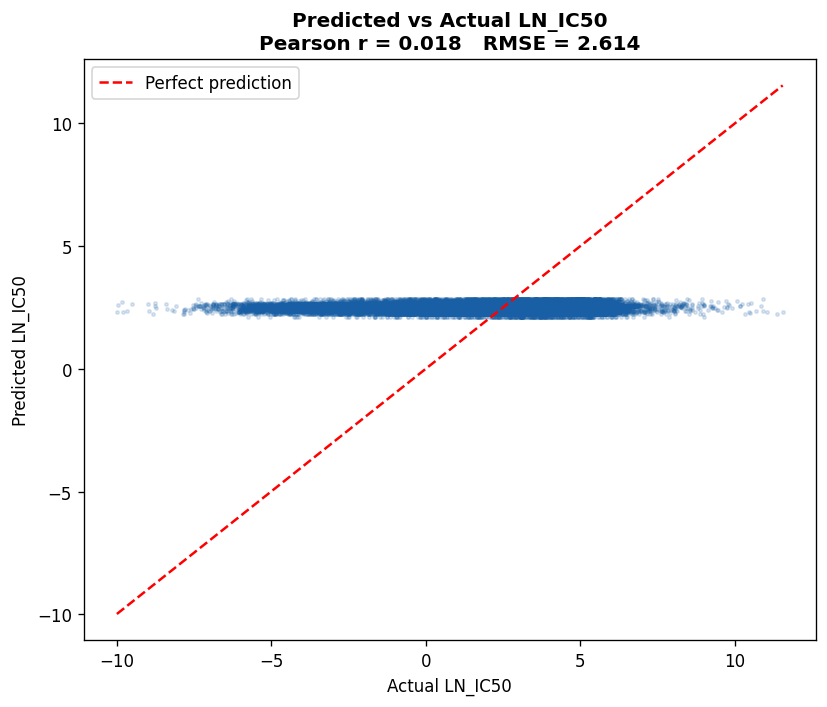

In [ ]:
# Rebuild X_test for evaluation
# (we deleted it to save RAM — rebuild just the test portion)
print("Rebuilding test matrix for evaluation...")
X_erl_test_eval, y_erl_test_eval = build_Xy_single_drug(
    test_labels, features_sel,
    features_sel.columns.tolist()
)

y_erl_pred = booster.predict(X_erl_test_eval,
                         num_iteration=booster.best_iteration)

r, p_value = pearsonr(y_erl_test_eval, y_erl_pred)
rmse = np.sqrt(mean_squared_error(y_erl_test_eval, y_erl_pred))

print("=" * 45)
print(f"  Pearson r:  {r:.4f}   (target: > 0.9)")
print(f"  RMSE:       {rmse:.4f}  (lower is better)")
print(f"  p-value:    {p_value:.2e}")
print("=" * 45)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_erl_test_eval, y_erl_pred, alpha=0.15, s=4,
           color='#185FA5', rasterized=True)
lims = [min(y_erl_test_eval.min(), y_erl_pred.min()),
        max(y_erl_test_eval.max(), y_erl_pred.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual LN_IC50')
ax.set_ylabel('Predicted LN_IC50')
ax.set_title(f'Predicted vs Actual LN_IC50\n'
             f'Pearson r = {r:.3f}   RMSE = {rmse:.3f}',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS + 'baseline_predictions.png', bbox_inches='tight')
plt.show()

# Erlotinib Per Drug Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import shap
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupShuffleSplit
import warnings, gc
warnings.filterwarnings('ignore')

DATA   = '/content/drive/MyDrive/anticancer_project/data/'
MODELS = '/content/drive/MyDrive/anticancer_project/models/'
PLOTS  = '/content/drive/MyDrive/anticancer_project/plots/'

plt.rcParams['figure.dpi'] = 120

print("Loading labels and features...")
labels   = pd.read_csv(MODELS + 'labels.csv')
features = pd.read_parquet(MODELS + 'features.parquet')

print(f"Labels:   {labels.shape}")
print(f"Features: {features.shape}")

Mounted at /content/drive
Loading labels and features...
Labels:   (204238, 7)
Features: (596, 39273)


Total Erlotinib experiments: 216
Unique cell lines:           216

LN_IC50 stats:
count    216.000
mean       2.526
std        1.123
min       -3.130
25%        2.184
50%        2.747
75%        3.166
max        4.278
Name: LN_IC50, dtype: float64


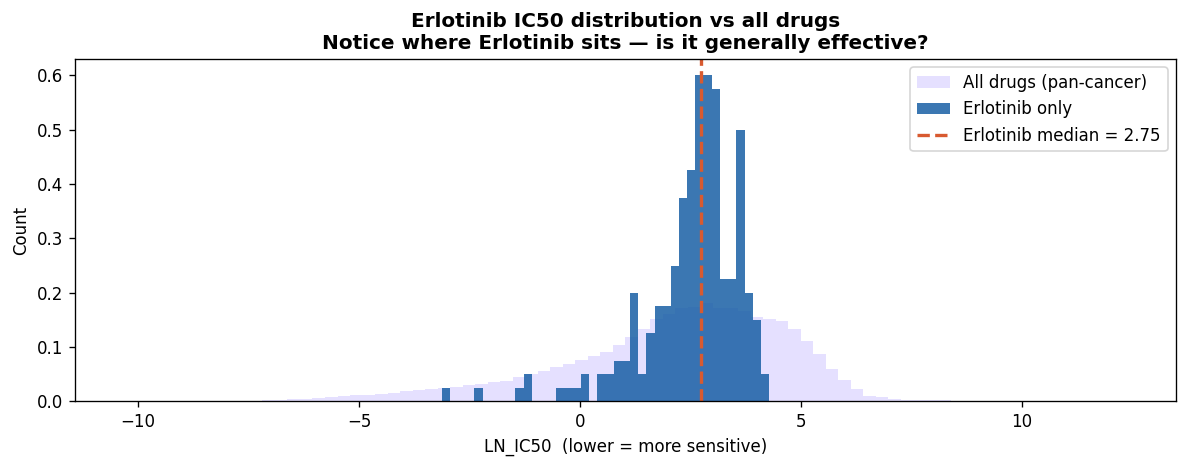

In [ ]:
# Pull out every experiment where Erlotinib was tested
erlotinib = labels[labels['DRUG_NAME'] == 'Erlotinib'].copy()
erlotinib = erlotinib.dropna(subset=['LN_IC50']).reset_index(drop=True)

print(f"Total Erlotinib experiments: {len(erlotinib)}")
print(f"Unique cell lines:           {erlotinib['CELL_LINE_NAME'].nunique()}")
print(f"\nLN_IC50 stats:")
print(erlotinib['LN_IC50'].describe().round(3))

# Compare to pan-cancer distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(labels['LN_IC50'].dropna(), bins=80, density=True,
        alpha=0.4, color='#BFB2FF', label='All drugs (pan-cancer)')
ax.hist(erlotinib['LN_IC50'], bins=40, density=True,
        alpha=0.85, color='#185FA5', label='Erlotinib only')
ax.axvline(erlotinib['LN_IC50'].median(), color='#D85A30',
           lw=2, ls='--',
           label=f"Erlotinib median = {erlotinib['LN_IC50'].median():.2f}")
ax.set_title('Erlotinib IC50 distribution vs all drugs\n'
             'Notice where Erlotinib sits — is it generally effective?',
             fontweight='bold')
ax.set_xlabel('LN_IC50  (lower = more sensitive)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS + 'erlotinib_distribution.png', bbox_inches='tight')
plt.show()

In [ ]:
# For a per-drug model we do feature selection differently
# We can now use VARIANCE across cell lines for Erlotinib specifically
# Same genes, but we only look at cell lines that were tested with Erlotinib

# Get the cell lines tested with Erlotinib
erl_cell_lines = erlotinib['CELL_LINE_NAME'].unique()
erl_cell_lines_upper = [c.upper() for c in erl_cell_lines]

# Filter features to those cell lines
features_erl = features[
    features.index.str.upper().isin(erl_cell_lines_upper)
].copy()

print(f"Cell lines with Erlotinib data: {len(features_erl)}")

# Separate expression from mutation columns
expr_cols     = [c for c in features.columns
                 if not c.endswith(('_hotspot','_damaging'))]
hotspot_cols  = [c for c in features.columns if c.endswith('_hotspot')]
damaging_cols = [c for c in features.columns if c.endswith('_damaging')]

# Top 2000 variable expression genes among Erlotinib cell lines
expr_var  = features_erl[expr_cols].var(axis=0)
top_genes = expr_var.nlargest(2000).index.tolist()

# Mutations present in ≥3% of Erlotinib-tested cell lines
n_min = max(3, int(0.03 * len(features_erl)))
hot_freq = features_erl[hotspot_cols].sum(axis=0)
dam_freq = features_erl[damaging_cols].sum(axis=0)
top_hot  = hot_freq[hot_freq >= n_min].index.tolist()
top_dam  = dam_freq[dam_freq >= n_min].index.tolist()

selected = top_genes + top_hot + top_dam
features_sel_erl = features[selected].copy()

print(f"\nSelected features:")
print(f"  Expression genes: {len(top_genes)}")
print(f"  Hotspot mutations: {len(top_hot)}")
print(f"  Damaging mutations: {len(top_dam)}")
print(f"  Total: {len(selected)}")

Cell lines with Erlotinib data: 216

Selected features:
  Expression genes: 2000
  Hotspot mutations: 11
  Damaging mutations: 212
  Total: 2223


In [ ]:
# Same GroupShuffleSplit strategy — never let same cell line
# appear in both train and test
splitter  = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(
    splitter.split(erlotinib,
                   groups=erlotinib['CELL_LINE_NAME'])
)

erl_train = erlotinib.iloc[train_idx].reset_index(drop=True)
erl_test  = erlotinib.iloc[test_idx].reset_index(drop=True)

# Verify no overlap
train_cls = set(erl_train['CELL_LINE_NAME'].str.upper())
test_cls  = set(erl_test['CELL_LINE_NAME'].str.upper())
overlap   = train_cls & test_cls

print(f"Training: {len(erl_train):,} rows, {len(train_cls)} cell lines")
print(f"Test:     {len(erl_test):,} rows,  {len(test_cls)} cell lines")
print(f"Overlap:  {len(overlap)} (must be 0)")

# Show cancer type breakdown in training set
print(f"\nCancer types in training set:")
if 'TCGA_DESC' in erl_train.columns:
    print(erl_train['TCGA_DESC'].value_counts())

Training: 172 rows, 172 cell lines
Test:     44 rows,  44 cell lines
Overlap:  0 (must be 0)

Cancer types in training set:
TCGA_DESC
UNCLASSIFIED    33
SCLC            18
DLBC            15
LAML            14
NB               9
LUAD             9
MM               8
ALL              8
GBM              7
BRCA             7
SKCM             6
COREAD           6
LCML             6
ESCA             5
LGG              4
STAD             3
CLL              3
MESO             2
LUSC             2
OV               1
MB               1
KIRC             1
PAAD             1
HNSC             1
PRAD             1
Name: count, dtype: int64


In [ ]:
def build_Xy_single_drug(label_df, feature_df, feature_cols):
    """
    Simpler than the pan-cancer version.
    No drug one-hot needed — every row is the same drug.
    Just look up cell line features directly.
    """
    cl_names = label_df['CELL_LINE_NAME'].str.upper().values
    y = label_df['LN_IC50'].values.astype('float32')

    n_rows = len(cl_names)
    n_cols = len(feature_cols)
    X = np.empty((n_rows, n_cols), dtype='float32')

    chunk_size = 5_000
    for start in range(0, n_rows, chunk_size):
        end = min(start + chunk_size, n_rows)
        X[start:end] = feature_df.loc[
            cl_names[start:end], feature_cols
        ].values

    return X, y

print("Building training matrix...")
X_train, y_train = build_Xy_single_drug(
    erl_train, features_sel_erl, selected
)

print("Building test matrix...")
X_test, y_test = build_Xy_single_drug(
    erl_test, features_sel_erl, selected
)

print(f"\nX_train: {X_train.shape}  —  {X_train.nbytes/1e6:.0f} MB")
print(f"X_test:  {X_test.shape}  —  {X_test.nbytes/1e6:.0f} MB")
print(f"\nNote: no drug columns this time — every row IS Erlotinib")

Building training matrix...
Building test matrix...

X_train: (172, 2223)  —  2 MB
X_test:  (44, 2223)  —  0 MB

Note: no drug columns this time — every row IS Erlotinib


In [ ]:
import subprocess
has_gpu = subprocess.run(['nvidia-smi'],
                        capture_output=True).returncode == 0
print(f"Device: {'GPU' if has_gpu else 'CPU'}")

# Convert to LightGBM Dataset
dtrain = lgb.Dataset(X_train, label=y_train, free_raw_data=True)
dtest  = lgb.Dataset(X_test,  label=y_test,
                     reference=dtrain, free_raw_data=True)

del X_train, X_test
gc.collect()
print("Raw arrays freed.")

params = {
    'objective':         'regression',
    'metric':            'rmse',
    'learning_rate':     0.03,    # slower — fewer training rows
    'num_leaves':        31,      # simpler trees — less data
    'min_child_samples': 10,      # fewer rows so lower threshold
    'subsample':         0.8,
    'colsample_bytree':  0.4,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'max_bin':           63,
    'device':            'gpu' if has_gpu else 'cpu',
    'n_jobs':            -1,
    'verbose':           -1,
    'random_state':      42,
}

print("\nTraining Erlotinib-specific model...")
print("Fewer rows than pan-cancer → trains much faster\n")

booster_erl = lgb.train(
    params,
    dtrain,
    num_boost_round = 1000,
    valid_sets      = [dtrain, dtest],
    valid_names     = ['train', 'test'],
    callbacks       = [
        lgb.early_stopping(80, verbose=True),
        lgb.log_evaluation(100)
    ]
)

print(f"\nBest iteration: {booster_erl.best_iteration}")

Device: GPU
Raw arrays freed.

Training Erlotinib-specific model...
Fewer rows than pan-cancer → trains much faster

Training until validation scores don't improve for 80 rounds
[100]	train's rmse: 0.358264	test's rmse: 1.08108
Early stopping, best iteration is:
[20]	train's rmse: 0.846454	test's rmse: 1.0339

Best iteration: 20


ERLOTINIB MODEL vs PAN-CANCER BASELINE
Metric                       Erlotinib   Pan-cancer
--------------------------------------------------
Pearson r                       0.1363       0.8800
RMSE                            1.0339       1.2239
Within 1 unit                    81.8%        62.8%
Within 0.5 units                 47.7%        35.4%


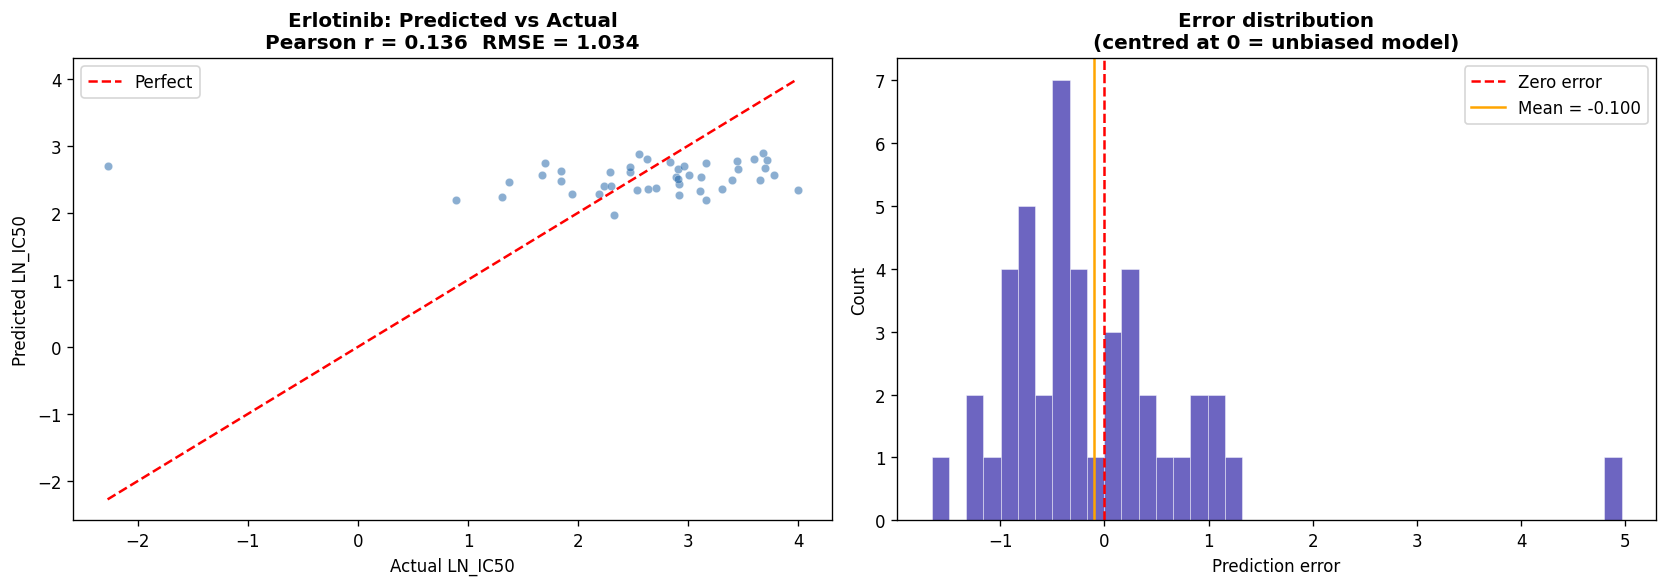

In [ ]:
# Rebuild test matrix for evaluation
X_test_eval, y_test_eval = build_Xy_single_drug(
    erl_test, features_sel_erl, selected
)

y_pred_erl = booster_erl.predict(
    X_test_eval.astype('float32'),
    num_iteration=booster_erl.best_iteration
)

r_erl,  _ = pearsonr(y_test_eval, y_pred_erl)
rmse_erl   = np.sqrt(mean_squared_error(y_test_eval, y_pred_erl))

errors = y_pred_erl - y_test_eval

print("=" * 50)
print("ERLOTINIB MODEL vs PAN-CANCER BASELINE")
print("=" * 50)
print(f"{'Metric':<25} {'Erlotinib':>12} {'Pan-cancer':>12}")
print("-" * 50)
print(f"{'Pearson r':<25} {r_erl:>12.4f} {'0.8800':>12}")
print(f"{'RMSE':<25} {rmse_erl:>12.4f} {'1.2239':>12}")
print(f"{'Within 1 unit':<25} {(np.abs(errors)<1.0).mean()*100:>11.1f}% {'62.8%':>12}")
print(f"{'Within 0.5 units':<25} {(np.abs(errors)<0.5).mean()*100:>11.1f}% {'35.4%':>12}")
print("=" * 50)

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_eval, y_pred_erl,
                alpha=0.5, s=25, color='#185FA5',
                edgecolors='white', linewidths=0.3)
lims = [min(y_test_eval.min(), y_pred_erl.min()),
        max(y_test_eval.max(), y_pred_erl.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect')
axes[0].set_xlabel('Actual LN_IC50')
axes[0].set_ylabel('Predicted LN_IC50')
axes[0].set_title(f'Erlotinib: Predicted vs Actual\n'
                  f'Pearson r = {r_erl:.3f}  RMSE = {rmse_erl:.3f}',
                  fontweight='bold')
axes[0].legend()

# Error distribution
axes[1].hist(errors, bins=40, color='#534AB7',
             alpha=0.85, edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='red', lw=1.5, ls='--', label='Zero error')
axes[1].axvline(errors.mean(), color='orange', lw=1.5,
                label=f'Mean = {errors.mean():.3f}')
axes[1].set_xlabel('Prediction error')
axes[1].set_ylabel('Count')
axes[1].set_title('Error distribution\n(centred at 0 = unbiased model)',
                  fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(PLOTS + 'erlotinib_evaluation.png', bbox_inches='tight')
plt.show()

In [ ]:
print("Computing SHAP values for Erlotinib model...")
print("This is the key result — EGFR should dominate\n")

# Use all test cell lines for SHAP (fewer rows than pan-cancer)
explainer_erl  = shap.TreeExplainer(booster_erl)
shap_values_erl = explainer_erl.shap_values(
    X_test_eval.astype('float32')
)

# Build importance table
shap_imp = pd.DataFrame({
    'feature':   selected,
    'shap_mean': np.abs(shap_values_erl).mean(axis=0)
}).sort_values('shap_mean', ascending=False)

# Tag feature types for coloring
def tag(f):
    if f.endswith('_hotspot'):  return 'hotspot'
    if f.endswith('_damaging'): return 'damaging'
    return 'expression'

shap_imp['type'] = shap_imp['feature'].apply(tag)

print("TOP 20 FEATURES FOR ERLOTINIB:")
print("=" * 45)
display(shap_imp.head(20))

# Check where EGFR is
egfr_rank = shap_imp.reset_index(drop=True)
egfr_rank = egfr_rank[egfr_rank['feature'].str.contains('EGFR')]
print(f"\nEGFR-related features:")
display(egfr_rank.head(5))

Computing SHAP values for Erlotinib model...
This is the key result — EGFR should dominate

TOP 20 FEATURES FOR ERLOTINIB:


,feature,shap_mean,type
83,PLS3,0.045795,expression
124,CAV2,0.039060,expression
372,SNAP25,0.018016,expression
1828,RGCC,0.017337,expression
501,PCP4,0.016409,expression
1605,ANKLE1,0.015491,expression
136,IGLL1,0.014713,expression
683,DUSP4,0.014035,expression
889,VPREB1,0.013362,expression
1872,NRXN1,0.011435,expression



EGFR-related features:


,feature,shap_mean,type
1316,EGFR,0.0,expression


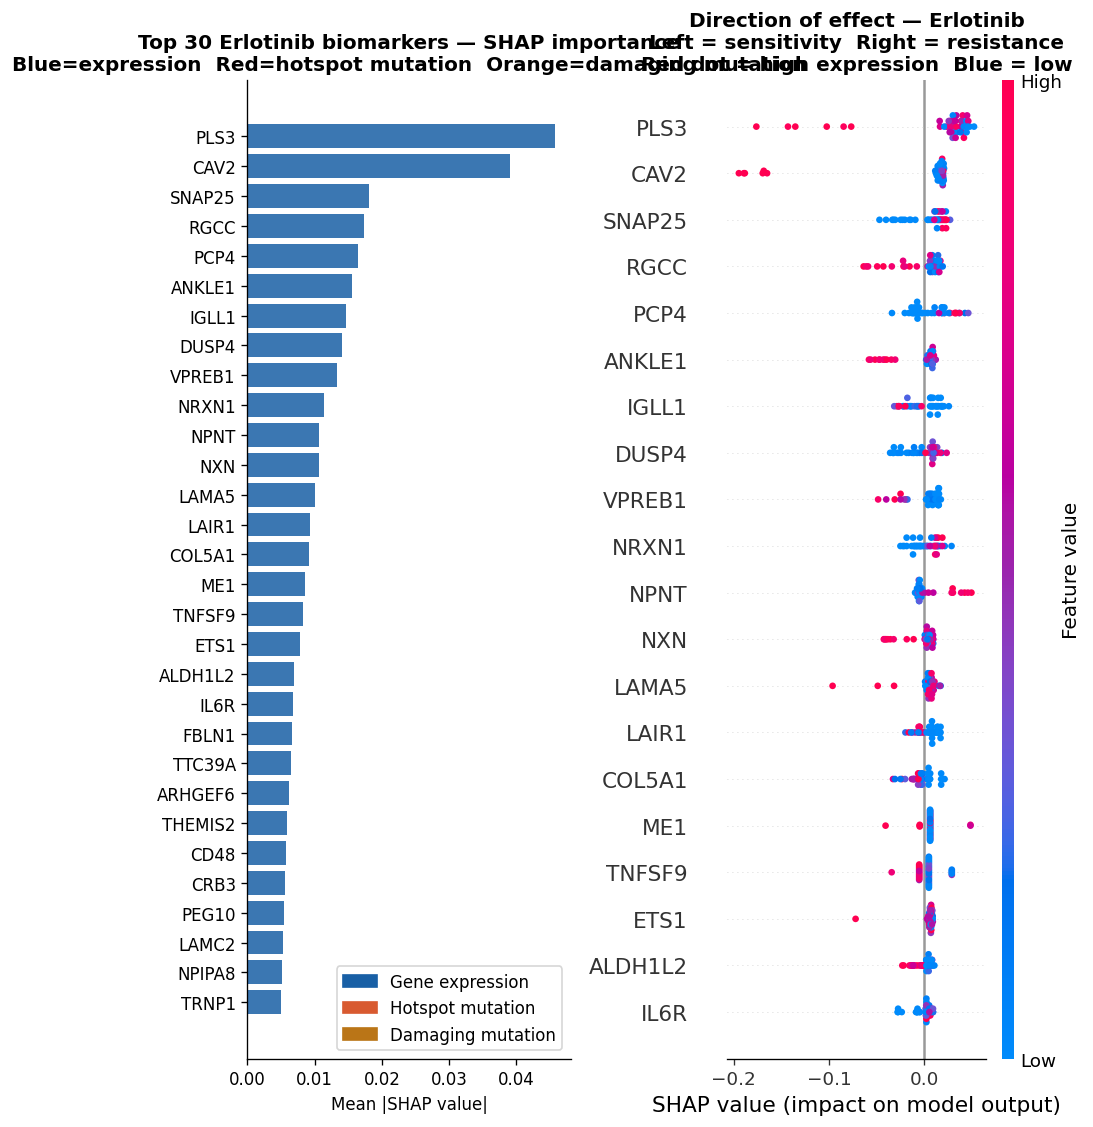

Erlotinib model saved.


In [ ]:
top30 = shap_imp.head(30)

color_map = {
    'expression': '#185FA5',
    'hotspot':    '#D85A30',
    'damaging':   '#BA7517'
}
colors = [color_map[t] for t in top30['type']]

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Left — bar chart
axes[0].barh(top30['feature'][::-1],
             top30['shap_mean'][::-1],
             color=colors[::-1], alpha=0.85)
axes[0].set_title('Top 30 Erlotinib biomarkers — SHAP importance\n'
                  'Blue=expression  Red=hotspot mutation  Orange=damaging mutation',
                  fontweight='bold')
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].spines[['top','right']].set_visible(False)

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#185FA5', label='Gene expression'),
    Patch(color='#D85A30', label='Hotspot mutation'),
    Patch(color='#BA7517', label='Damaging mutation'),
])

# Right — SHAP summary dot plot (shows direction)
shap.summary_plot(
    shap_values_erl[:, :len(top_genes)],
    X_test_eval[:, :len(top_genes)],
    feature_names=top_genes,
    max_display=20,
    show=False,
    plot_type='dot'
)
plt.title('Direction of effect — Erlotinib\n'
          'Left = sensitivity  Right = resistance\n'
          'Red dot = high expression  Blue = low',
          fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS + 'erlotinib_biomarkers.png', bbox_inches='tight')
plt.show()

# Save model
booster_erl.save_model(MODELS + 'lgbm_erlotinib.txt')
print("Erlotinib model saved.")